In [53]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load data
student_data = pd.read_csv("./student_performance_interactions.csv")

In [46]:
columns_to_drop = [
    'student_id', 
    'final_score',
    # variables beneath can be commented out
    'previous_score',
    'math_prev_score',
    'grade',
    'science_prev_score',
    'language_prev_score',
    'pass_fail'
]

X = student_data.drop(columns=columns_to_drop, errors='ignore')
y = student_data['final_score']

X = pd.get_dummies(X, dtype='uint8')

In [47]:
# Train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)

Training set: (800, 14) (800,)
Validation set: (200, 14) (200,)


In [48]:
# Train model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [49]:
y_val_pred = model.predict(X_val)

In [50]:
# Evaluation
mse = mean_squared_error(y_val, y_val_pred)
r2 = r2_score(y_val, y_val_pred)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)
print("Out-of-Bag Score:", model.oob_score_)

Mean Squared Error: 59.18975250413898
R^2 Score: 0.705624231927701
Out-of-Bag Score: 0.6751175884903124


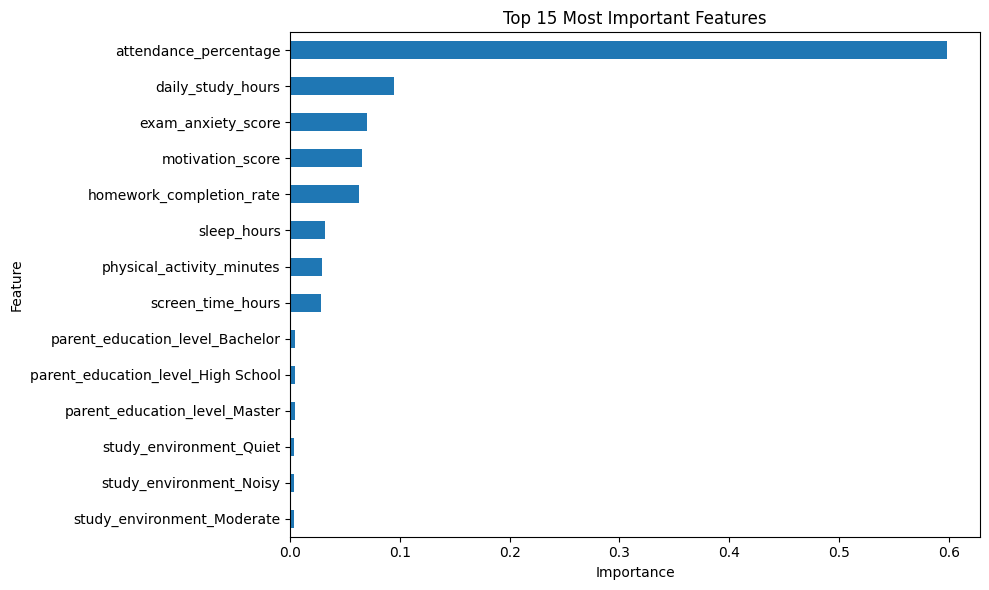

In [51]:
feature_importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Plot top 15 features
top_features = feature_importances.head(15)

plt.figure(figsize=(10,6))
top_features.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

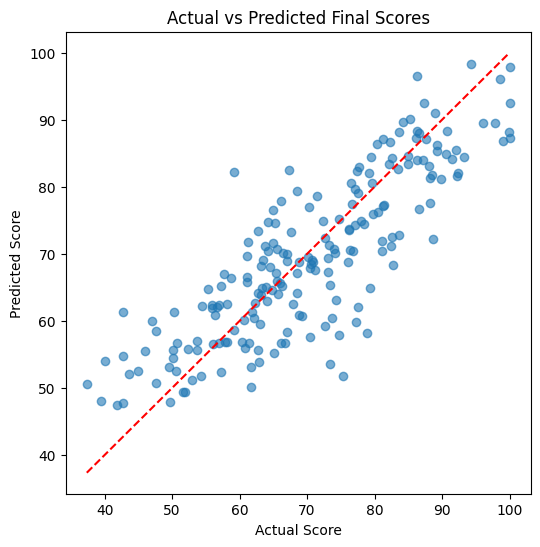

In [52]:
plt.figure(figsize=(6,6))

plt.scatter(y_val, y_val_pred, alpha=0.6)
plt.plot([y_val.min(), y_val.max()],
         [y_val.min(), y_val.max()],
         'r--')

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Final Scores")
plt.show()